# MedGemma 4B — Assistant radiologue virtuel (version propre & intégrée au dépôt)

> **Prototype pédagogique. Non destiné au diagnostic. Validation par un professionnel qualifié requise.**

Cette version :
- clone le dépôt et réutilise **ses garde-fous et ses métriques** (cohérence avec le rendu) ;
- garde votre approche « classification en un mot », plus fiable que le JSON brut ;
- structure chaque sortie au **schéma JSON du projet** ;
- produit **toutes les métriques minimales** (dont sensibilité, spécificité, latence) ;
- fournit matrice de confusion, analyse d'erreurs et rapatriement des fichiers.

**Avant de lancer :** `Exécution > Modifier le type d'exécution > GPU` (T4).

## 1. Cloner le dépôt, installer, vérifier le GPU
On n'upgrade **pas** Pillow (source du bug `_Ink`). Le clone est rejouable.

In [1]:
import os
if not os.path.exists('DS-7C-assistant-radiologue-virtuel'):
    !git clone https://github.com/TonneauBenjamin/DS-7C-assistant-radiologue-virtuel.git
%cd /content/DS-7C-assistant-radiologue-virtuel
!pip install -q -U transformers accelerate bitsandbytes sentencepiece kagglehub
!nvidia-smi -L

Cloning into 'assistant-radiologue-virtuel'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 90 (delta 6), reused 1 (delta 1), pack-reused 72 (from 1)
Receiving objects: 100% (90/90), 952.23 KiB | 3.41 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/assistant-radiologue-virtuel
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.0 MB/s eta 0:00:00
GPU 0: Tesla T4 (UUID: GPU-5b361696-6cdd-f7a1-7315-c154ff5734f4)


### Mettre à jour `src/metrics.py`
On réécrit le module de métriques avec la version complète (accuracy, macro-F1, **sensibilité**, **spécificité**, taux JSON/warning/incertitude, **latence médiane**). C'est aussi ce fichier qu'il faudra committer dans le repo.

In [3]:
%%writefile src/metrics.py
from __future__ import annotations

from collections import Counter
from statistics import median
from typing import Iterable, Optional

CLASSES = ["normal", "suspected_opacity", "uncertain"]


def accuracy(y_true: Iterable[str], y_pred: Iterable[str]) -> float:
    y_true = list(y_true); y_pred = list(y_pred)
    if not y_true:
        return 0.0
    return sum(a == b for a, b in zip(y_true, y_pred)) / len(y_true)


def macro_f1(y_true: Iterable[str], y_pred: Iterable[str], classes: list[str] = CLASSES) -> float:
    y_true = list(y_true); y_pred = list(y_pred)
    scores = []
    for c in classes:
        tp = sum(t == c and p == c for t, p in zip(y_true, y_pred))
        fp = sum(t != c and p == c for t, p in zip(y_true, y_pred))
        fn = sum(t == c and p != c for t, p in zip(y_true, y_pred))
        precision = tp / (tp + fp) if tp + fp else 0
        recall = tp / (tp + fn) if tp + fn else 0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
        scores.append(f1)
    return sum(scores) / len(scores)


def confusion_counts(y_true: Iterable[str], y_pred: Iterable[str]) -> dict[str, int]:
    counts = Counter()
    for t, p in zip(y_true, y_pred):
        counts[f"{t}__{p}"] += 1
    return dict(counts)


def class_recall(y_true: Iterable[str], y_pred: Iterable[str], target: str) -> Optional[float]:
    """Rappel d'une classe = (bien classes) / (tous les cas de cette classe).

    Sensibilite = class_recall(..., 'suspected_opacity')
    Specificite = class_recall(..., 'normal')
    Renvoie None si aucun cas de cette classe (denominateur nul).
    """
    y_true = list(y_true); y_pred = list(y_pred)
    support = sum(t == target for t in y_true)
    if support == 0:
        return None
    correct = sum(t == target and p == target for t, p in zip(y_true, y_pred))
    return correct / support


def summarize_metrics(rows: list[dict]) -> dict[str, float]:
    y_true = [r["label"] for r in rows]
    y_pred = [r["predicted_class"] for r in rows]
    json_valid = [r.get("json_valid", True) for r in rows]
    warnings = [bool(r.get("warning")) for r in rows]
    latencies = [float(r["latency_ms"]) for r in rows if r.get("latency_ms") is not None]

    sens = class_recall(y_true, y_pred, "suspected_opacity")
    spec = class_recall(y_true, y_pred, "normal")

    return {
        "n": len(rows),
        "accuracy": round(accuracy(y_true, y_pred), 4),
        "macro_f1": round(macro_f1(y_true, y_pred), 4),
        "sensitivity_opacity": round(sens, 4) if sens is not None else None,
        "specificity_normal": round(spec, 4) if spec is not None else None,
        "json_valid_rate": round(sum(json_valid) / len(json_valid), 4) if rows else 0,
        "warning_rate": round(sum(warnings) / len(warnings), 4) if rows else 0,
        "uncertain_rate": round(sum(p == "uncertain" for p in y_pred) / len(y_pred), 4) if rows else 0,
        "median_latency_ms": round(median(latencies), 1) if latencies else None,
    }


Overwriting src/metrics.py


## 2. Connexion Hugging Face
MedGemma est *gated* : accepter les conditions sur https://huggingface.co/google/medgemma-4b-it, puis coller un token *read*.

In [4]:
from huggingface_hub import login
login()  # colle ton token hf_...

## 3. Charger MedGemma 4B en 8-bit (une seule fois)

In [5]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

MODEL_ID = 'google/medgemma-4b-it'
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=BitsAndBytesConfig(load_in_8bit=True),
    device_map='auto',
)
print("MedGemma 4B chargé en 8-bit.")

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

MedGemma 4B chargé.


## 4. Dataset Kaggle → jeu au format du projet
Token Kaggle : `kaggle.com` → Settings → API → *Create New Token*. On construit `data/real_cases.csv` (NORMAL → `normal`, PNEUMONIA → `suspected_opacity`).

In [6]:
import kagglehub
kagglehub.login()  # username + key

Kaggle credentials set.
Kaggle credentials successfully validated.


In [7]:
import csv, shutil, random
from pathlib import Path
import kagglehub

N_PAR_CLASSE = 12   # 12 + 12 = 24 cas (cible du barème : 20 à 30)
random.seed(0)

base = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))
test_root = next(base.rglob('test'))

def pick(sub, n):
    fs = sorted((test_root / sub).glob('*.jpeg')) + sorted((test_root / sub).glob('*.jpg'))
    random.shuffle(fs); return fs[:n]

normal, pneumo = pick('NORMAL', N_PAR_CLASSE), pick('PNEUMONIA', N_PAR_CLASSE)
dst = Path('data/real_cases'); dst.mkdir(parents=True, exist_ok=True)
rows = []
for i, f in enumerate(normal + pneumo):
    label = 'normal' if f in normal else 'suspected_opacity'
    cid = f'CXR_REAL_{i:03d}_{label}'
    out = dst / f'{cid}{f.suffix.lower()}'; shutil.copy(f, out)
    rows.append({'case_id': cid, 'image_path': str(out), 'source': 'kaggle_pneumonia_ccby4',
                 'label': label, 'split': 'final', 'quality': 'good', 'notes': 'real public CXR'})
with open('data/real_cases.csv', 'w', newline='', encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
print(f'{len(rows)} cas écrits dans data/real_cases.csv')

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
24 cas écrits dans data/real_cases.csv


## 5. Fonction de prédiction au schéma du projet
Votre approche « un mot » (fiable) est **enveloppée dans le schéma JSON du projet**, puis passée par `apply_safety_guardrails`. Ainsi le taux de JSON valide et le warning sont garantis, tout en gardant une classification robuste.

Mapping : `PNEUMONIA → suspected_opacity`, `NORMAL → normal`, sinon `uncertain`.

In [10]:
import re, time, torch
from PIL import Image
from src.guardrails import apply_safety_guardrails, WARNING_TEXT

EOT = processor.tokenizer.convert_tokens_to_ids("<end_of_turn>")
PAD = processor.tokenizer.pad_token_id or 0

def classer(txt, mode):
    # Choix de conception : ne trancher que sur une ligne FINAL explicite. Toute
    # sortie improved ambigue ou tronquee retombe volontairement sur `uncertain`
    # (defere a l'humain plutot que de risquer une classe erronee).
    up = txt.upper()
    m = re.search(r"FINAL\s*:\s*(PNEUMONIA|NORMAL)", up)
    if m:
        return ("suspected_opacity", 0.85) if m.group(1) == "PNEUMONIA" else ("normal", 0.80)
    if mode == "baseline":
        debut = up[:40]
        if "PNEUMON" in debut:
            return "suspected_opacity", 0.75
        if "NORMAL" in debut:
            return "normal", 0.75
    return "uncertain", 0.40


def predire(img_path, cfg, debug=False):
    image = Image.open(img_path).convert('RGB')
    messages = [
        {'role':'system','content':[{'type':'text','text':cfg['system']}]},
        {'role':'user','content':[{'type':'text','text':cfg['user']},{'type':'image','image':image}]},
    ]
    inputs = processor.apply_chat_template(messages, add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors='pt').to(model.device)
    input_len = inputs['input_ids'].shape[-1]
    t0 = time.time()
    with torch.inference_mode():
        gen = model.generate(**inputs, max_new_tokens=cfg['max_new_tokens'], do_sample=False,
            eos_token_id=EOT, pad_token_id=PAD,
            repetition_penalty=1.3, no_repeat_ngram_size=3)
    latency_ms = int((time.time() - t0) * 1000)
    txt = processor.decode(gen[0][input_len:], skip_special_tokens=True)
    pred, conf = classer(txt, cfg['name'])
    if debug:
        print('RAW:', repr(txt[:200]), '->', pred)
    result = {
        'image_quality':'good','predicted_class':pred,'confidence':conf,
        'visual_evidence':[txt.strip()[:160]] if txt.strip() else [],
        'justification':txt.strip()[:300],
        'limitations':['no clinical context','not a validated medical model','pediatric dataset'],
        'warning':WARNING_TEXT,'model_name':f"medgemma-4b-it-{cfg['name']}",
        'prompt_version':f"{cfg['name']}_v1",'latency_ms':latency_ms,
    }
    return apply_safety_guardrails(result)

### Définition des deux prompts (baseline vs improved)

In [ ]:
# Les deux consignes comparees : baseline (simple) vs improved (prudente).
PROMPTS = {
    'baseline': {'name': 'baseline',
        'system': 'You are an expert radiologist.',
        'user': 'Look at this chest X-ray. Answer with exactly one word: NORMAL if the '
                'lungs are clear, or PNEUMONIA if there is a lung opacity or consolidation.',
        'max_new_tokens': 10},
    'improved': {'name': 'improved',
        'system': 'You are an expert chest radiologist. Missing a pneumonia is dangerous, '
                  'so when there is ANY sign of opacity, consolidation or infiltrate, classify as PNEUMONIA.',
        'user': 'Analyze this chest X-ray step by step, then end with a final line exactly in '
                'the form "FINAL: NORMAL" or "FINAL: PNEUMONIA".',
        'max_new_tokens': 160},
}
print('PROMPTS defini : baseline + improved')

In [14]:
cases = list(__import__('csv').DictReader(open('data/real_cases.csv', encoding='utf-8')))
for c in cases[:3]:
    predire(c['image_path'], PROMPTS['baseline'], debug=True)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


RAW: 'NORMAL\n' -> normal
RAW: 'NORMAL\n' -> normal
RAW: 'NORMAL\n' -> normal


## 6. Baseline vs Improved + toutes les métriques
On réutilise `summarize_metrics` du dépôt. Sortie : les CSV attendus dans `eval/outputs/`.

In [ ]:
import csv, json
from pathlib import Path
from src.metrics import summarize_metrics
from src.guardrails import validate_prediction   # <-- import manquant corrige

cases = list(csv.DictReader(open('data/real_cases.csv', encoding='utf-8')))
Path('eval/outputs').mkdir(parents=True, exist_ok=True)
summary, all_rows = [], {}
for mode, cfg in PROMPTS.items():
    rows = []
    for c in cases:
        pred = predire(c['image_path'], cfg)
        valid, errors = validate_prediction(pred)
        rows.append({'case_id': c['case_id'], 'label': c['label'],
                     'predicted_class': pred['predicted_class'], 'confidence': pred['confidence'],
                     'json_valid': valid, 'warning': pred.get('warning', ''),
                     'latency_ms': pred.get('latency_ms', 0), 'guardrail_errors': ';'.join(errors)})
    metrics = summarize_metrics(rows)
    summary.append({'mode': mode, **metrics}); all_rows[mode] = rows
    with open(f'eval/outputs/{mode}_real_predictions.csv', 'w', newline='', encoding='utf-8') as fh:
        w = csv.DictWriter(fh, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
    print(f'[{mode}] termine')

with open('eval/outputs/before_after_real.csv', 'w', newline='', encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=list(summary[0].keys())); w.writeheader(); w.writerows(summary)
print(json.dumps(summary, indent=2))

## 7. Matrice de confusion + sensibilité / spécificité
La matrice n'est pas exigée telle quelle, mais c'est le chemin naturel vers la **sensibilité** et la **spécificité** (elles, obligatoires).

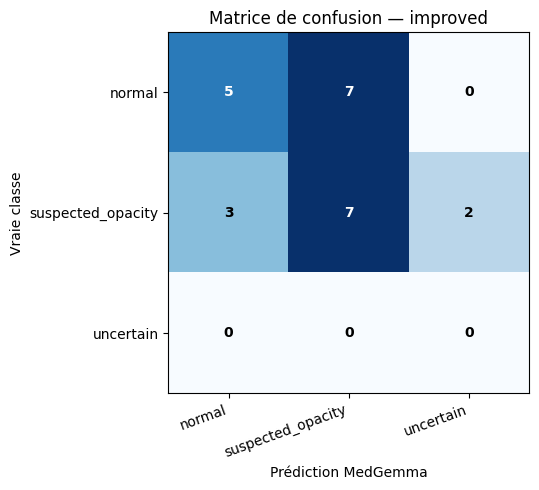

Sensibilité (opacity) : 0.5833
Spécificité (normal)  : 0.4167
Latence médiane (ms)  : 41590.0


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from src.metrics import confusion_counts

MODE = 'improved'   # change en 'baseline' pour comparer
rows = all_rows[MODE]
y_true = [r['label'] for r in rows]; y_pred = [r['predicted_class'] for r in rows]
classes = ['normal', 'suspected_opacity', 'uncertain']
cc = confusion_counts(y_true, y_pred)
mat = np.array([[cc.get(f'{t}__{p}', 0) for p in classes] for t in classes])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mat, cmap='Blues')
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, mat[i, j], ha='center', va='center',
                color='white' if mat[i, j] > mat.max()/2 else 'black', fontweight='bold')
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=20, ha='right'); ax.set_yticklabels(classes)
ax.set_xlabel('Prédiction MedGemma'); ax.set_ylabel('Vraie classe')
ax.set_title(f'Matrice de confusion — {MODE}')
plt.tight_layout(); plt.show()

m = next(s for s in summary if s['mode'] == MODE)
print('Sensibilité (opacity) :', m['sensitivity_opacity'])
print('Spécificité (normal)  :', m['specificity_normal'])
print('Latence médiane (ms)  :', m['median_latency_ms'])

## 8. Analyse d'erreurs — faux négatifs / faux positifs
Pré-remplit le registre d'erreurs. **Ne montrez pas que des réussites** en soutenance.

In [17]:
import csv
rows = all_rows['improved']
reg = []
for r in rows:
    gt, pr = r['label'], r['predicted_class']
    if gt == 'suspected_opacity' and pr == 'normal':
        etype, sev = 'FN', 'high'      # pneumonie ratée = le plus grave
    elif gt == 'normal' and pr == 'suspected_opacity':
        etype, sev = 'FP', 'medium'
    elif pr == 'uncertain':
        etype, sev = 'UA', 'low'
    else:
        continue
    reg.append({'case_id': r['case_id'], 'ground_truth': gt, 'prediction': pr,
                'error_type': etype, 'severity': sev, 'comment': '', 'corrective_action': ''})

with open('eval/error_register_filled.csv', 'w', newline='', encoding='utf-8') as fh:
    cols = ['case_id','ground_truth','prediction','error_type','severity','comment','corrective_action']
    w = csv.DictWriter(fh, fieldnames=cols); w.writeheader(); w.writerows(reg)
print(f'{len(reg)} cas à commenter → eval/error_register_filled.csv')
for x in reg: print(x['case_id'], x['error_type'], x['severity'])

12 cas à commenter → eval/error_register_filled.csv
CXR_REAL_000_normal FP medium
CXR_REAL_001_normal FP medium
CXR_REAL_002_normal FP medium
CXR_REAL_004_normal FP medium
CXR_REAL_006_normal FP medium
CXR_REAL_007_normal FP medium
CXR_REAL_010_normal FP medium
CXR_REAL_013_suspected_opacity FN high
CXR_REAL_014_suspected_opacity FN high
CXR_REAL_020_suspected_opacity UA low
CXR_REAL_021_suspected_opacity UA low
CXR_REAL_022_suspected_opacity FN high


## 9. Rapatriement vers le dépôt
Télécharge les fichiers à committer. ⚠️ `eval/outputs/` est *gitignored* : range les CSV dans `docs/resultats/` **ou** force-les avec `git add -f`.

In [ ]:
import shutil, os
os.makedirs('a_rapatrier/docs_resultats', exist_ok=True)
for f in ['baseline_real_predictions.csv','improved_real_predictions.csv','before_after_real.csv']:
    shutil.copy(f'eval/outputs/{f}', f'a_rapatrier/docs_resultats/{f}')
shutil.copy('eval/error_register_filled.csv', 'a_rapatrier/error_register_filled.csv')
shutil.copy('data/real_cases.csv', 'a_rapatrier/real_cases.csv')
shutil.copy('src/metrics.py', 'a_rapatrier/metrics.py')
shutil.make_archive('a_rapatrier', 'zip', 'a_rapatrier')
from google.colab import files
files.download('a_rapatrier.zip')
print('Zip prêt. Dézippe et copie chaque fichier au bon endroit dans ton repo.')